In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
# matplotlib.use('agg')
import matplotlib.pyplot as plt
import os
# from tqdm.notebook import  tqdm
from tqdm import  tqdm
import talib
import datetime
import math
import  mplfinance as mpf

import sys
sys.path.append('../../DataSource/baostock')
import datasource 
sys.path.append('../..')
import Utils
# 这个是筛选多少天上涨多少的，
codes = datasource.getAStockCodes()
print(f'股票数量:{len(codes)},第一支股票:{codes[0]}')
code = codes[0]
dt = datasource.getData(code)
dt.head()

import scipy.cluster.hierarchy as sch

import seaborn as sns
import matplotlib.pyplot as plt

股票数量:2460,第一支股票:sh.600000


In [2]:
# 我这里直接构造相关系数矩阵吧，因为有些股票刚刚上市，数量不多，还有些停止上市的，所以这里只要那些完全的
days = []
for i in range(20):
    dt = datasource.getData(codes[i], '2025-1-1')
    days.append(len(dt))
print(','.join([str(j) for j in days]))

145,0,0,0,145,0,145,145,145,145,145,145,145,145,145,145,145,145,145,145


In [3]:
# 到现在145天，所以这里只是取得145天的
MAX_DAYS = max(days)
print(MAX_DAYS)

145


In [4]:
bars = {} # 股票数据保存到这里
for i in range(len(codes)):
    dt = datasource.getData(codes[i], '2025-1-1')
    # 只有有这个数量的才进入下一步处理
    if len(dt) == MAX_DAYS:
        bars[codes[i]] = dt['close'].tolist()

In [5]:
dt_all = pd.DataFrame(bars) # 组成数据
# 2. 计算相关系数矩阵
corr_matrix = dt_all.corr()
# 核心修复：把因为常数项或缺失值导致的 NaN/Inf 统一填补为 0
corr_matrix = corr_matrix.fillna(0)
corr_matrix[np.isinf(corr_matrix)] = 0 
# 3. 使用层次聚类对相关系数进行排序
# 此时矩阵中全是有限数值，可以安全执行
Z = sch.linkage(corr_matrix.values, method='ward', metric='euclidean')
# 4. 获取最优的排序索引
new_order_indices = sch.leaves_list(Z)

# 5. 根据新索引重新调整横轴和纵轴
new_order_names = corr_matrix.index[new_order_indices].tolist()
reordered_corr_matrix = corr_matrix.iloc[new_order_indices, new_order_indices]

print("--- 调整后的结果 ---")
print(f"优化后的名称顺序: {new_order_names}")
print("\n调整后的二维相关系数矩阵：")
print(reordered_corr_matrix)

# # 一键生成聚类热力图
# # col_cluster=True, row_cluster=True 保证横轴纵轴同时按聚类顺序调整
# sns.clustermap(corr_matrix, cmap='vlag', annot=True, figsize=(6, 6))
# plt.show()

--- 调整后的结果 ---
优化后的名称顺序: ['sh.600643', 'sh.600941', 'sh.601728', 'sh.600018', 'sh.605199', 'sz.000001', 'sh.605580', 'sh.601288', 'sh.603903', 'sh.601166', 'sh.601818', 'sz.000638', 'sz.000963', 'sh.600252', 'sh.600340', 'sh.603363', 'sz.000858', 'sh.600000', 'sh.600104', 'sh.601633', 'sz.000766', 'sh.600203', 'sz.000921', 'sh.600243', 'sh.600535', 'sh.600619', 'sh.603486', 'sh.603767', 'sh.600196', 'sh.600276', 'sh.601607', 'sh.603517', 'sh.601579', 'sh.600212', 'sh.600557', 'sh.603030', 'sh.603717', 'sh.600530', 'sh.600857', 'sh.601766', 'sh.603567', 'sh.605008', 'sh.600696', 'sh.603392', 'sh.603878', 'sh.601456', 'sh.603322', 'sh.600660', 'sh.600975', 'sz.000876', 'sh.600438', 'sz.000679', 'sh.600107', 'sh.600521', 'sh.600167', 'sh.603815', 'sh.600976', 'sh.601658', 'sh.603508', 'sh.603657', 'sh.600381', 'sz.000567', 'sh.603359', 'sh.603535', 'sz.000564', 'sh.603277', 'sz.000625', 'sh.600187', 'sh.603589', 'sz.000166', 'sh.603983', 'sz.000004', 'sh.600085', 'sh.600809', 'sh.601186',

In [6]:
# 我这里期望做出一个图形出来
type(reordered_corr_matrix)

pandas.DataFrame

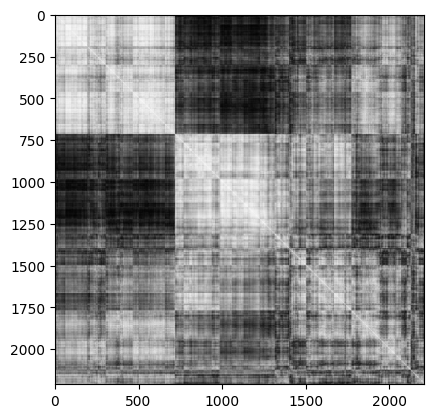

In [7]:
# 若数据为浮点数，需转换到0-255
df_normalized = ((reordered_corr_matrix - reordered_corr_matrix.min()) / (reordered_corr_matrix.max() - reordered_corr_matrix.min()) * 255).astype(np.uint8)
plt.imshow(df_normalized.values, cmap='gray', vmin=0, vmax=255)

In [13]:
columns = df_normalized.columns.tolist()
','.join([columns[i] for i in range(700)])

'sh.600643,sh.600941,sh.601728,sh.600018,sh.605199,sz.000001,sh.605580,sh.601288,sh.603903,sh.601166,sh.601818,sz.000638,sz.000963,sh.600252,sh.600340,sh.603363,sz.000858,sh.600000,sh.600104,sh.601633,sz.000766,sh.600203,sz.000921,sh.600243,sh.600535,sh.600619,sh.603486,sh.603767,sh.600196,sh.600276,sh.601607,sh.603517,sh.601579,sh.600212,sh.600557,sh.603030,sh.603717,sh.600530,sh.600857,sh.601766,sh.603567,sh.605008,sh.600696,sh.603392,sh.603878,sh.601456,sh.603322,sh.600660,sh.600975,sz.000876,sh.600438,sz.000679,sh.600107,sh.600521,sh.600167,sh.603815,sh.600976,sh.601658,sh.603508,sh.603657,sh.600381,sz.000567,sh.603359,sh.603535,sz.000564,sh.603277,sz.000625,sh.600187,sh.603589,sz.000166,sh.603983,sz.000004,sh.600085,sh.600809,sh.601186,sz.001206,sh.600918,sh.601788,sh.601881,sh.600436,sh.600793,sh.601236,sh.600657,sh.600197,sz.000799,sz.001356,sz.001391,sh.600702,sh.605009,sh.600050,sh.601086,sh.603369,sh.600518,sh.600597,sh.601990,sh.603569,sh.600095,sh.601878,sh.605188,sz.000752